# Applyting SPOD to PIV data from different actuation periods

In [1]:
import numpy as np
import os, glob, json, gc
from spod_utils import compute_spod, load_spod_npz, summarize_run, run_sort_key
from data_utils import plot_spod_mode
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"

## Load data, compute SPOD and store results

In [7]:
# === CONFIG ===

input_folder = "compressed_data"
output_folder = "SPOD_data"

# Parameters for SPOD
n_fft = 256
n_modes = None  # keep all available modes

# ===

# Loop over all .npz files in the folder
for fname in os.listdir(input_folder):
    if fname.endswith("_PIV_compressed.npz"):
        fpath = os.path.join(input_folder, fname)
        print(f"Processing {fname}...")

        # Load compressed dataset
        data = np.load(fpath)
        u, v = data["u"], data["v"]
        X, Y = data["X"], data["Y"]

        # Compute SPOD
        freqs, eigvals, eigvecs = compute_spod(u, v, n_fft=n_fft, n_modes=n_modes)

        # Build output filename
        out_name = fname.replace("_compressed.npz", "_SPOD.npz")
        out_path = os.path.join(output_folder, out_name)

        # Save results compressed
        np.savez_compressed(out_path,
                            freqs=freqs,
                            eigvals=eigvals,
                            eigvecs=eigvecs,
                            X=X,
                            Y=Y)

        print(f"Saved SPOD results to {out_path}")

        del u, v, X, Y, freqs, eigvals, eigvecs
        gc.collect()

Processing RUN1_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN1_PIV_SPOD.npz
Processing RUN2_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN2_PIV_SPOD.npz
Processing RUN3_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN3_PIV_SPOD.npz
Processing RUN4_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN4_PIV_SPOD.npz
Processing RUN5_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN5_PIV_SPOD.npz
Processing RUN6_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN6_PIV_SPOD.npz
Processing RUN7_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN7_PIV_SPOD.npz
Processing RUN8_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN8_PIV_SPOD.npz
Processing RUN9_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN9_PIV_SPOD.npz
Processing RUN10_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN10_PIV_SPOD.npz
Processing RUN11_PIV_compressed.npz...
Saved SPOD results to SPOD_data\RUN11_PIV_SPOD.npz
Processing RUN12_PIV_compres

## Spectra-only comparison

In this section, I will compare SPOD reults of all runs but without looking at the eigenvectors (modes), so I will compare eigenvalues (energy corresponding to each mode) at each frequency for each dataset.

In [4]:
# === CONFIG ===

SPOD_DIR = "SPOD_data"        # folder with *_SPOD.npz files
K_ENERGY = 5                  # energy captured by first K modes

# ===

files = sorted(glob.glob(os.path.join(SPOD_DIR, "*_SPOD.npz")))
if not files:
    raise FileNotFoundError(f"No *_SPOD.npz found in {SPOD_DIR}")

runs = []
for f in files:
    name = os.path.basename(f).replace("_SPOD.npz","")
    freqs, eigvals = load_spod_npz(f)
    summ = summarize_run(freqs, eigvals, k_energy=K_ENERGY)
    runs.append({"name": name, "path": f, **summ})
    del eigvals; gc.collect()

runs_sorted = sorted(runs, key=run_sort_key)

### Total energy vs frequency (per run, normalized for visibility)

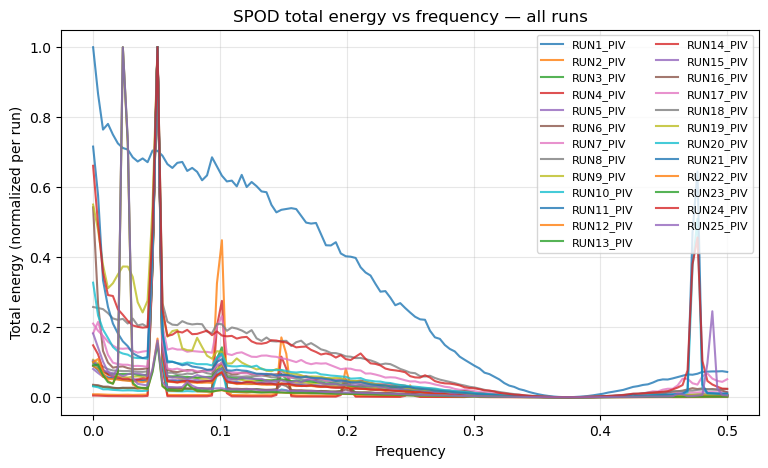

In [4]:
plt.figure(figsize=(9,5))
for r in runs_sorted:
    y = r["total_energy"] / (r["total_energy"].max() + 1e-12)
    plt.plot(r["freqs"], y, alpha=0.8, label=r["name"])
plt.xlabel("Frequency")
plt.ylabel("Total energy (normalized per run)")
plt.title("SPOD total energy vs frequency — all runs")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

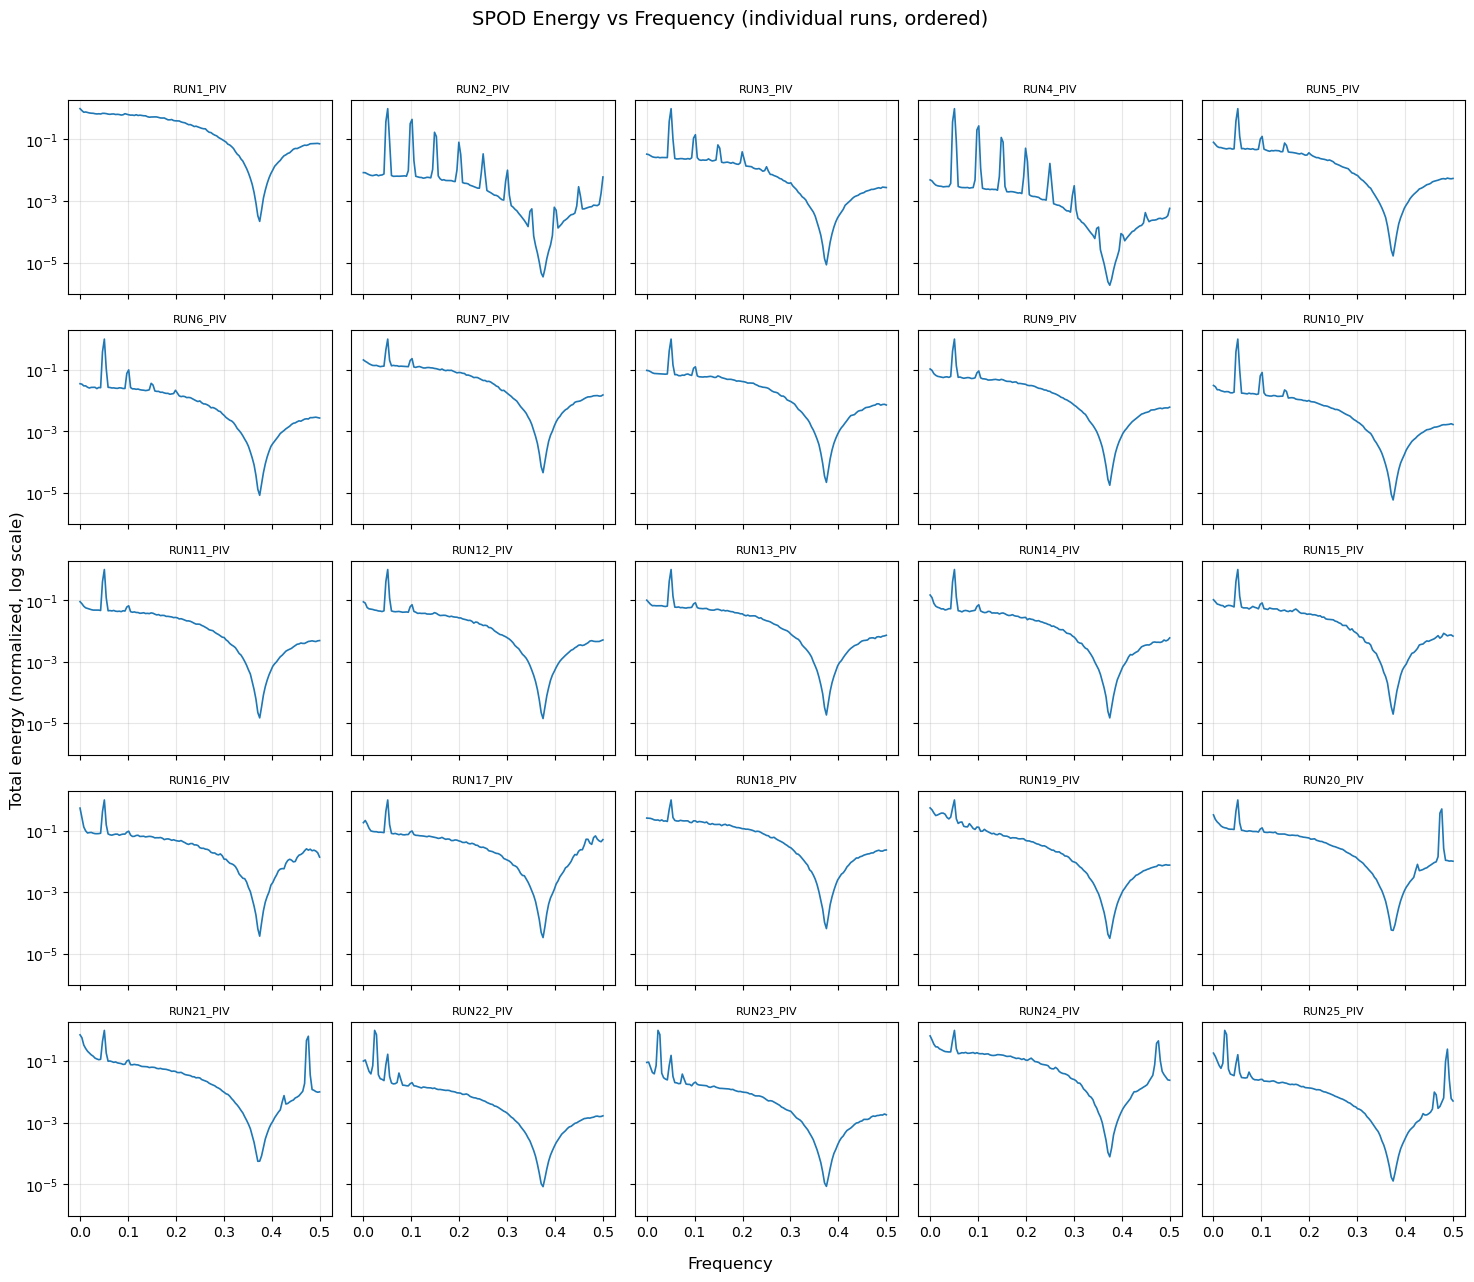

In [5]:
# Grid parameters
ncols = 5    # 5 subplots per row
n_runs = len(runs_sorted)
nrows = 5
figsize = (3*ncols, 2.5*nrows)

fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

for i, r in enumerate(runs_sorted):
    ax = axes[i]
    y = r["total_energy"] / (r["total_energy"].max() + 1e-12)
    ax.plot(r["freqs"], y, lw=1.2, color="tab:blue")
    ax.set_title(r["name"], fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")     # log scale for more detail


fig.suptitle("SPOD Energy vs Frequency (individual runs, ordered)", fontsize=14, y=1.02)
fig.supxlabel("Frequency", fontsize=12)
fig.supylabel("Total energy (normalized, log scale)", fontsize=12)
plt.tight_layout()
plt.show()

Most runs show clear peaks at multiples of 0.05. My hypothesis is that this happens because the data are aligned with the actuation period, so the SPOD sees a repeating signal and highlights the forcing frequency and its harmonics. Some runs keep a lot of strong peaks, which means the actuation produces many harmonics, while in others the peaks decay quickly, showing that the response is dominated by the main frequency only.

### Energy fraction captured by first K modes (K = K_ENERGY)

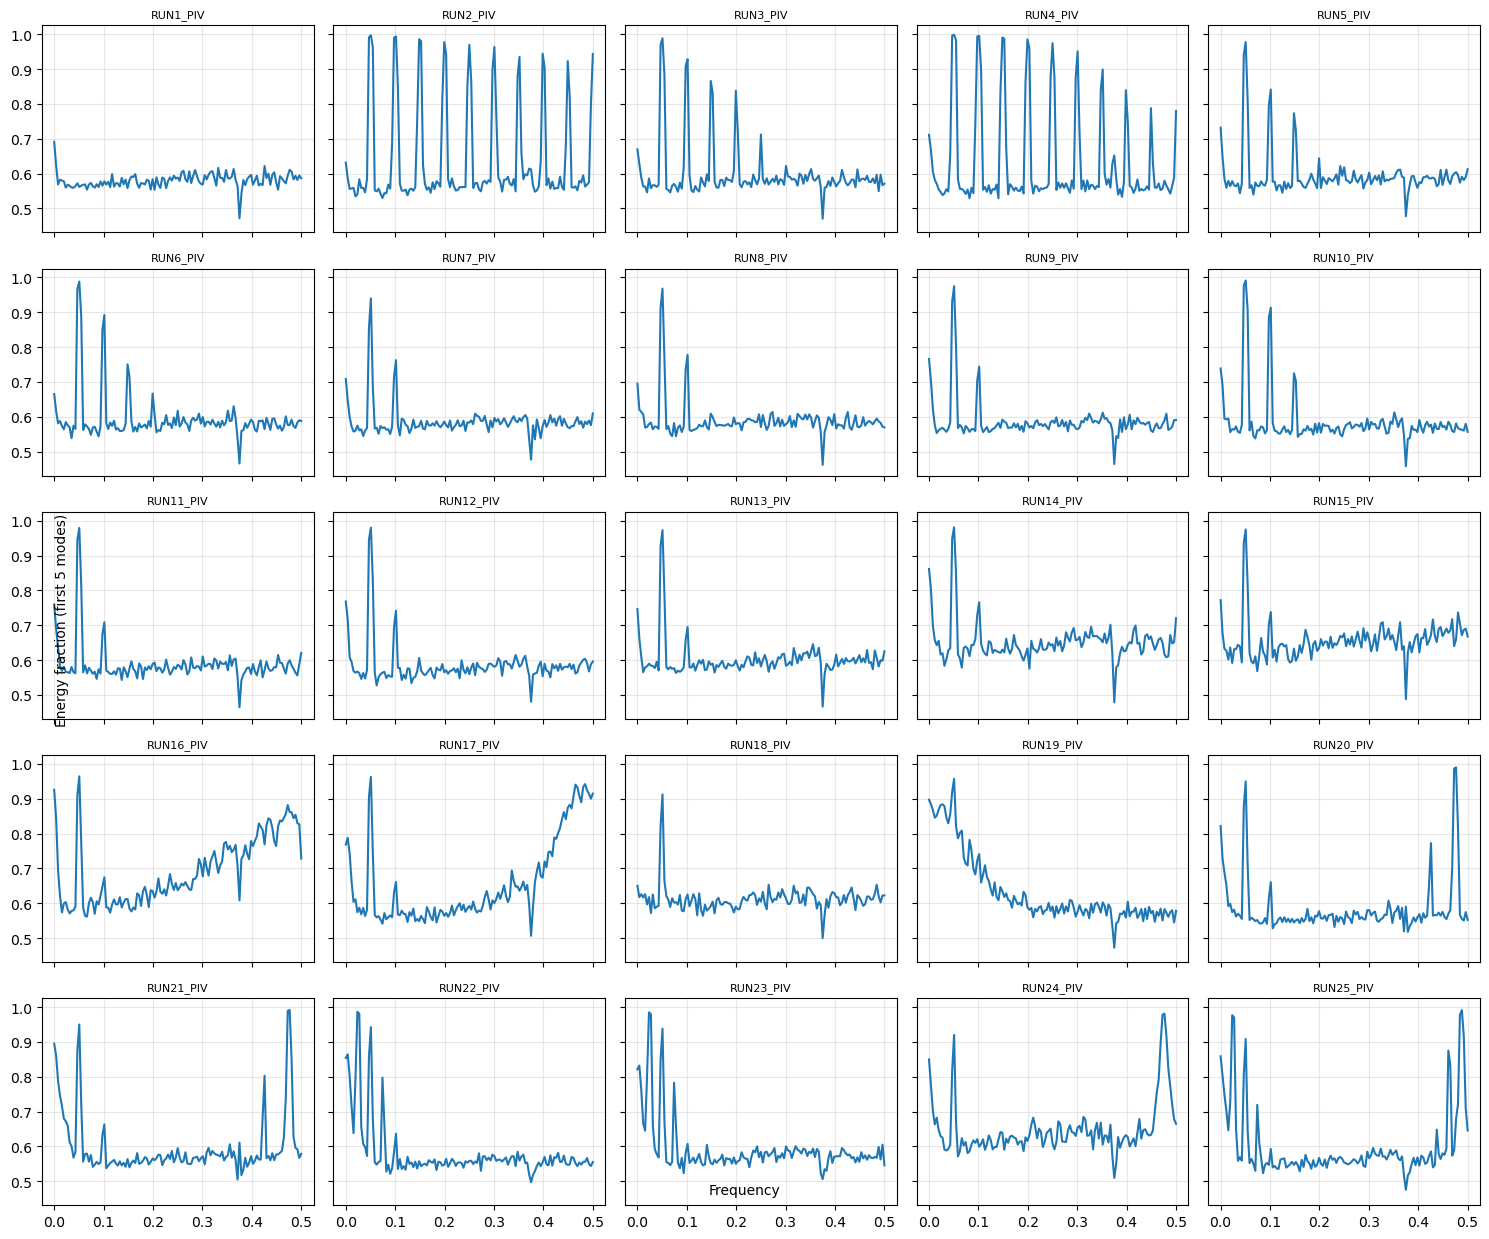

In [8]:
n = len(runs_sorted)
ncols = 5
nrows = 5
figsize = (3*ncols, 2.5*nrows)

fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

for i, r in enumerate(runs_sorted):
    axes[i].plot(r["freqs"], r["cum_energy_first_k"])
    axes[i].set_title(r["name"], fontsize=8)
    axes[i].grid(True, alpha=0.3)

# remove unused panels
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.text(0.5, 0.04, "Frequency", ha="center")
fig.text(0.04, 0.5, f"Energy fraction (first {K_ENERGY} modes)", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

This plot shows the fraction of energy captured by the first 5 SPOD modes. The peaks appear at the same frequencies as in the energy spectra, which means that at those frequencies a few dominant modes explain most of the energy. This indicates the presence of coherent structures locked to the actuation and its harmonics. Between peaks, the energy fraction drops, showing that the flow is more disorganized and spread over many modes. The differences across runs reflect how strongly each actuation Strouhal organizes the flow.

### Leading normalized eigenvalue across runs (energy fraction captured by first mode)

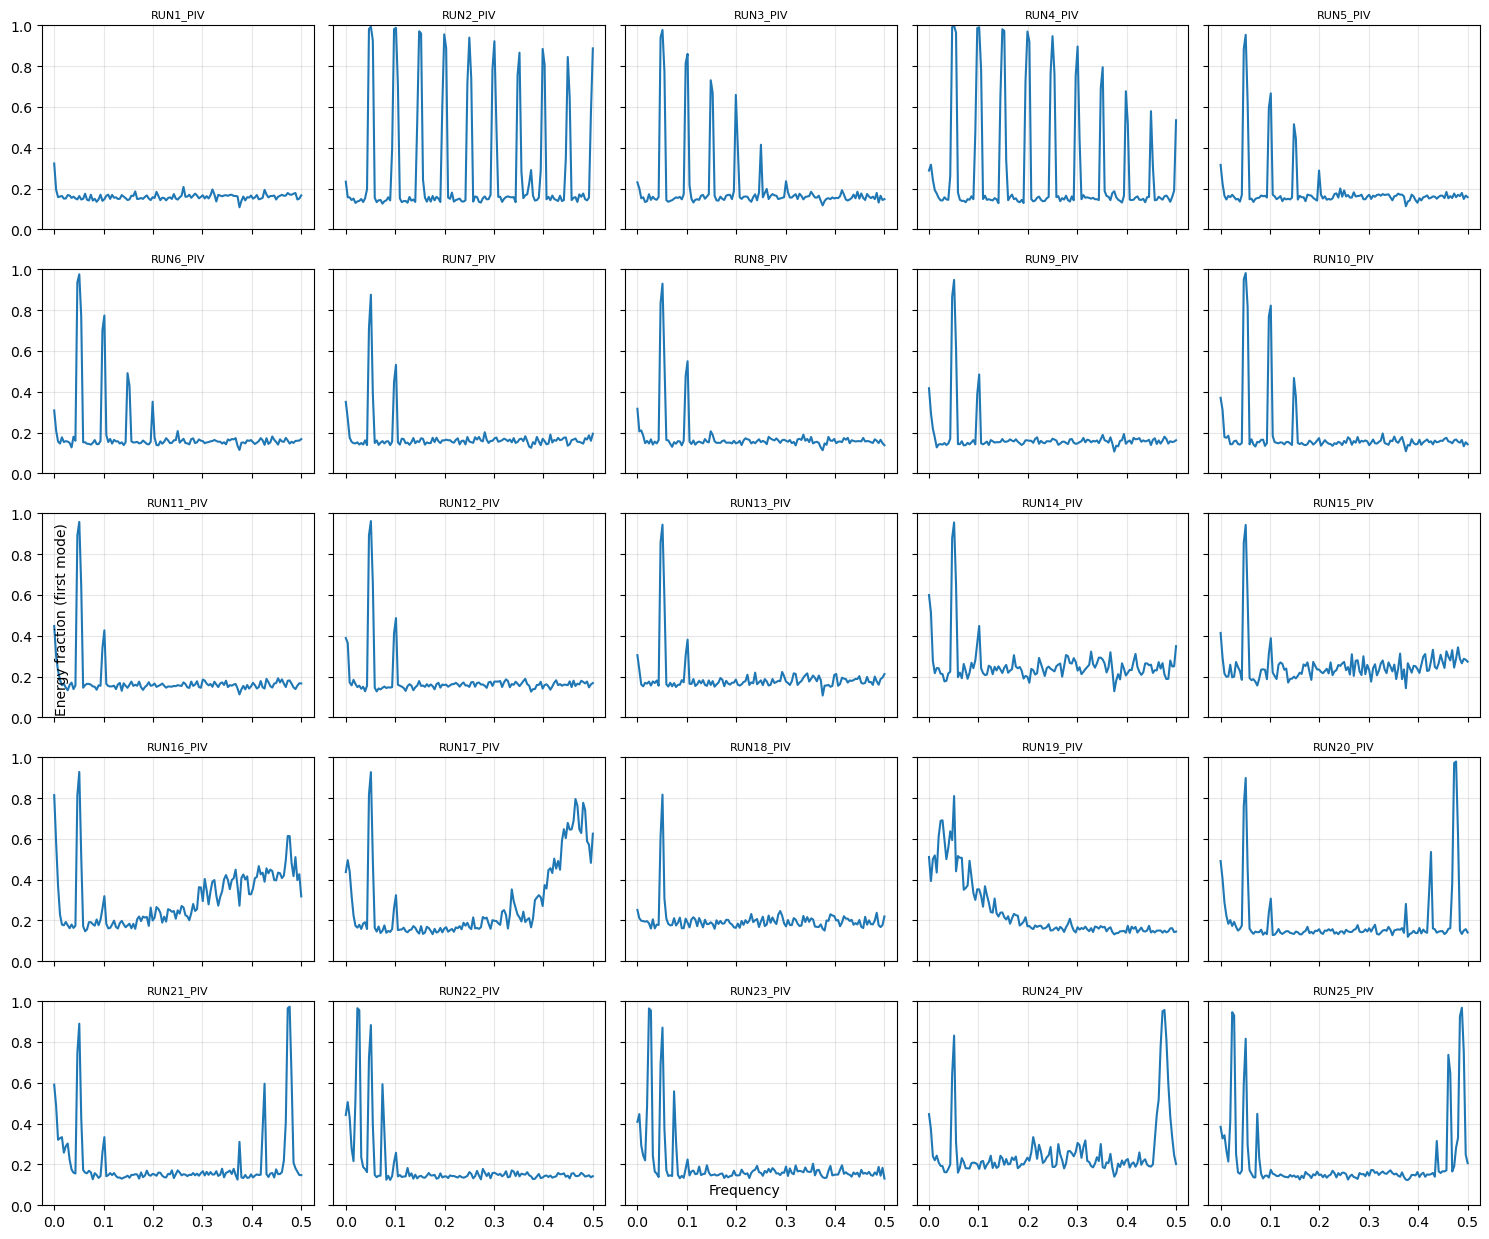

In [9]:
n = len(runs_sorted)
ncols = 5
nrows = 5
figsize = (3*ncols, 2.5*nrows)

fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

for i, r in enumerate(runs_sorted):
    axes[i].plot(r["freqs"], r["eigvals_norm"][:, 0])
    axes[i].set_title(r["name"], fontsize=8)
    axes[i].set_ylim(0, 1)
    axes[i].grid(True, alpha=0.3)

# remove unused panels
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.text(0.5, 0.04, "Frequency", ha="center")
fig.text(0.04, 0.5, f"Energy fraction (first mode)", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

These results show that the actuation not only injects energy at specific frequencies but, in many cases, makes the flow almost one-dimensional at those frequencies, with a single SPOD mode carrying nearly all the energy.

The fact that some runs show many coherent peaks while others only have one dominant frequency suggests that the jet does not respond equally to all forcing Strouhals. When the actuation frequency resonates with the natural shear-layer instabilities, the flow locks in and generates harmonics, leading to multiple coherent structures. In other runs, the forcing is less effective and only the fundamental frequency appears strongly, with the rest of the energy spread across many modes.

### Heatmaps with frequency alignment

This plot gives the same information as the previous one. It is just another way of visualizing it

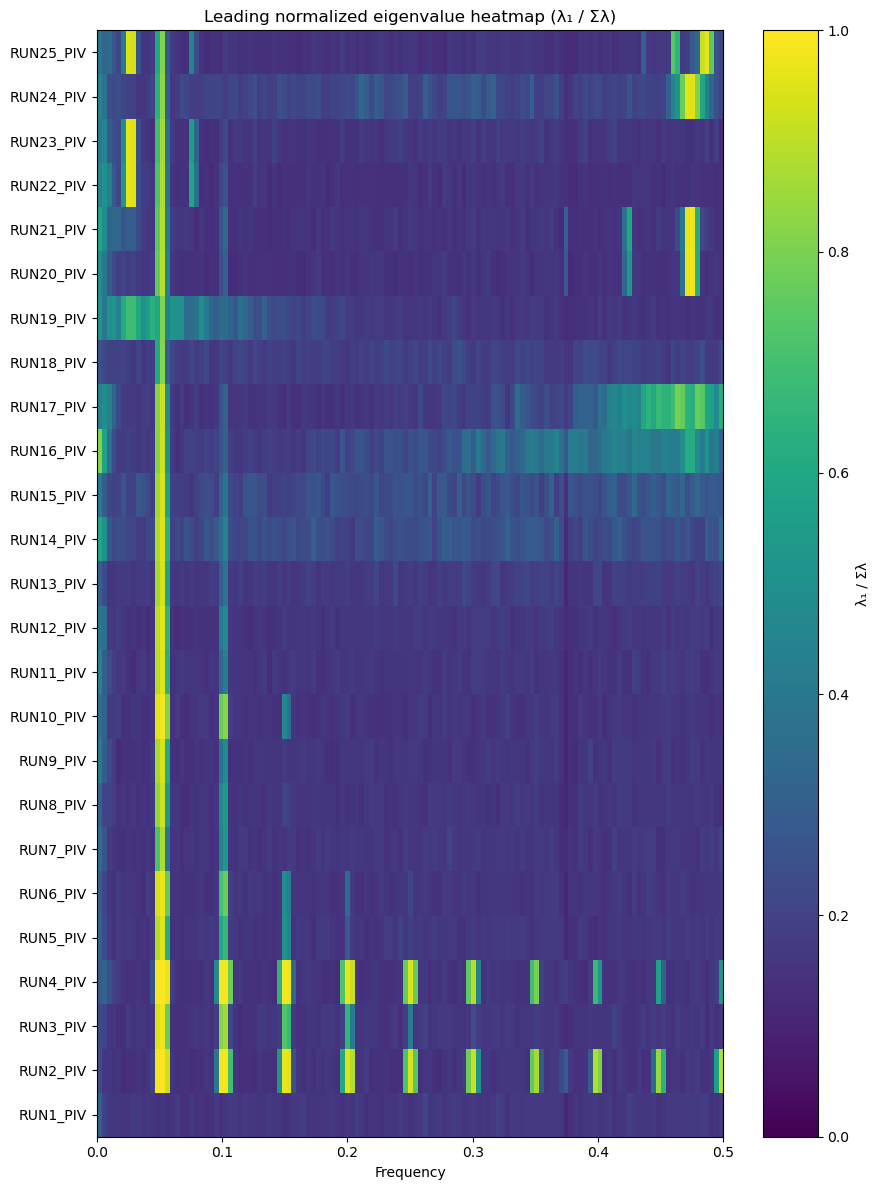

In [15]:
freqs = runs_sorted[0]["freqs"]                 # common frequency grid
M = np.vstack([r["eigvals_norm"][:, 0] for r in runs_sorted])  # shape: (n_runs, n_freq)
labels = [r["name"] for r in runs_sorted]

plt.figure(figsize=(9, 0.4*len(runs_sorted)+2))
plt.imshow(M, aspect="auto", origin="lower",
           extent=[freqs.min(), freqs.max(), 0, len(runs_sorted)],
           vmin=0, vmax=1)
plt.colorbar(label="λ₁ / Σλ")
plt.yticks(np.arange(len(labels)) + 0.5, labels)
plt.xlabel("Frequency")
plt.title("Leading normalized eigenvalue heatmap (λ₁ / Σλ)")
plt.tight_layout()
plt.show()

## Mode-shape comparison

My initial plan included comparing the most energetic modes to try and find the specific structures in the fluid. However, I now think this can be out of the scope of my thesis, since this process would be related with phisics rather than statistics. I will just plot the most energetic mode from RUN2 at f=0.1 to see if there is any fluid structure visible.

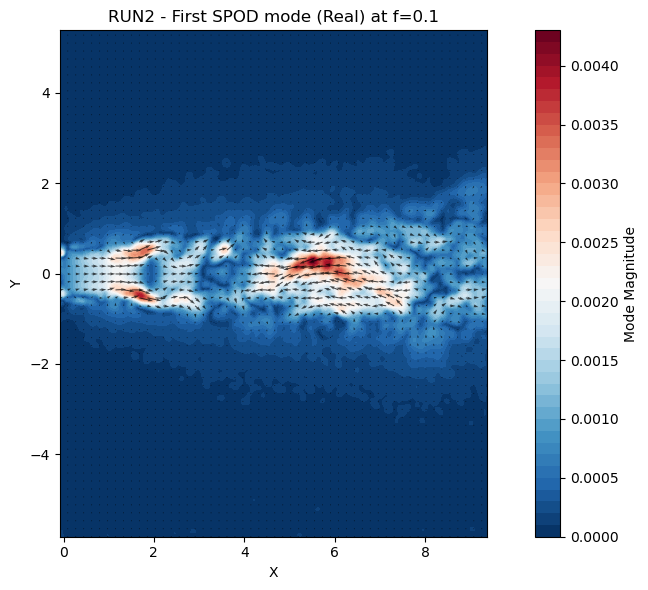

In [10]:
# Load SPOD results for RUN2
data = np.load("SPOD_data/RUN2_PIV_SPOD.npz")

freqs   = data["freqs"]
eigvecs = data["eigvecs"]
X       = data["X"]
Y       = data["Y"]

# --- pick frequency f=0.05 ---
i_freq = np.argmin(np.abs(freqs - 0.1))

# first mode (mode 0)
phi = eigvecs[i_freq, 0]

# Depending on storage: if U,V are concatenated
nx, ny = X.shape

# --- Real part ---
U_mode_real = np.real(phi[:nx*ny]).reshape(nx, ny)
V_mode_real = np.real(phi[nx*ny:]).reshape(nx, ny)


plot_spod_mode(X, Y, [U_mode_real, V_mode_real],
               title="RUN2 - First SPOD mode (Real) at f=0.1",
               scale=0.1, quiver_step=5)

# POD vs SPOD Comparison for Phase-Averaged PIV Data

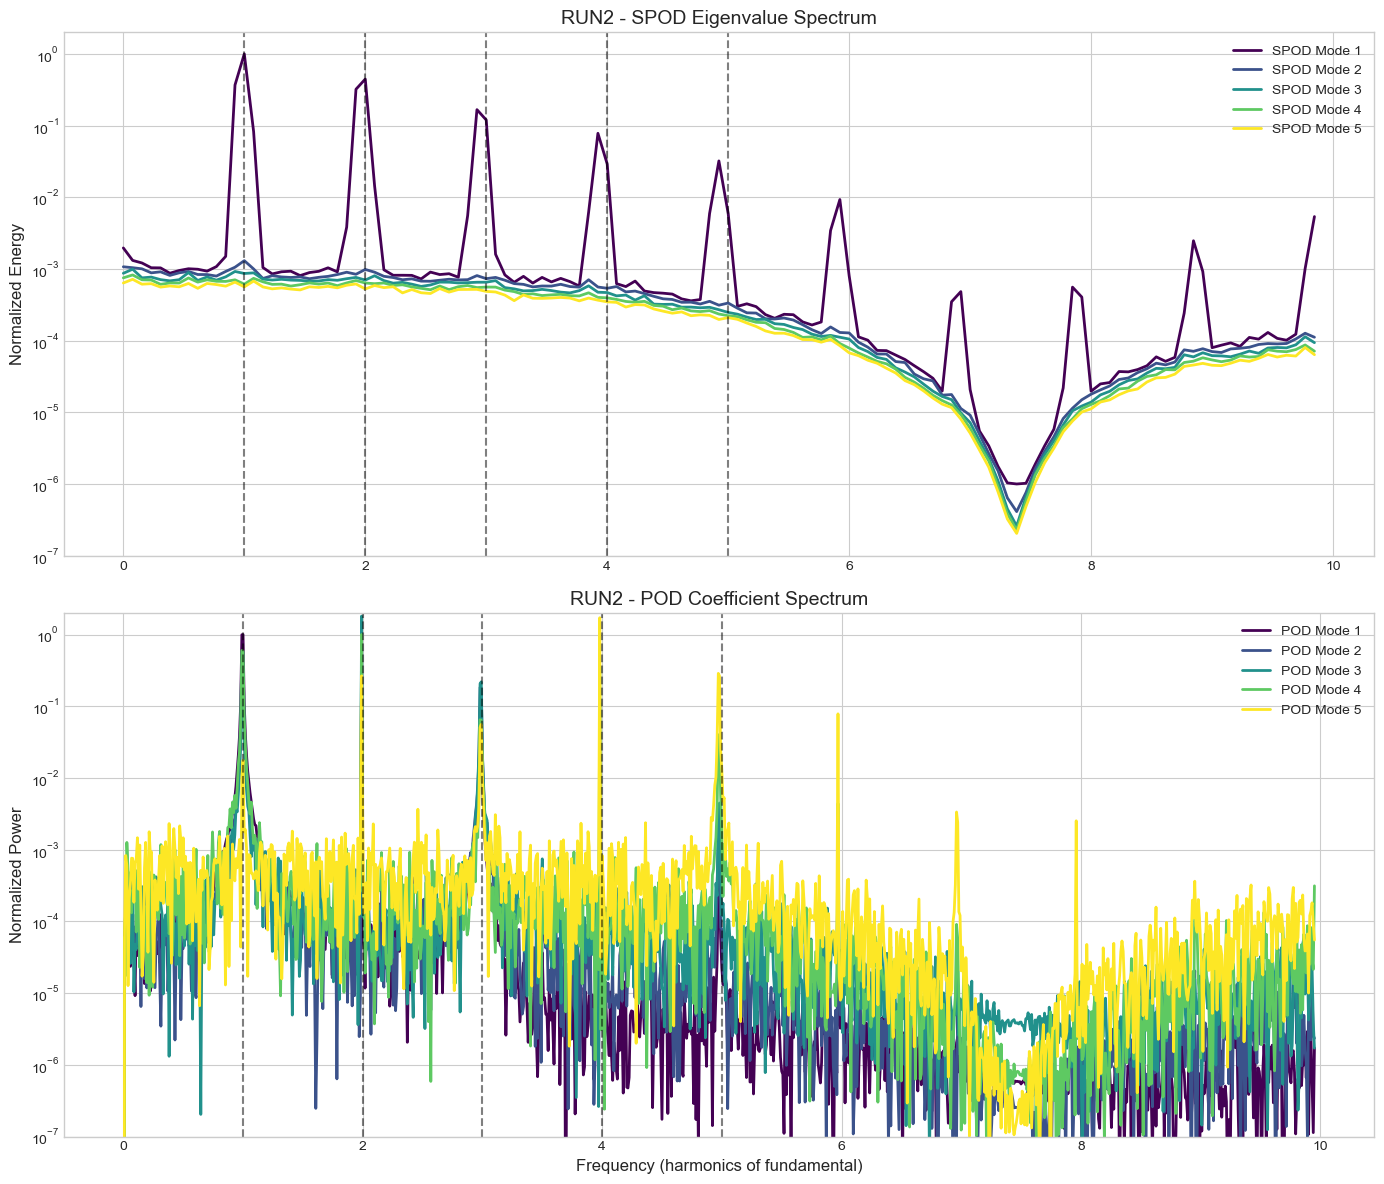

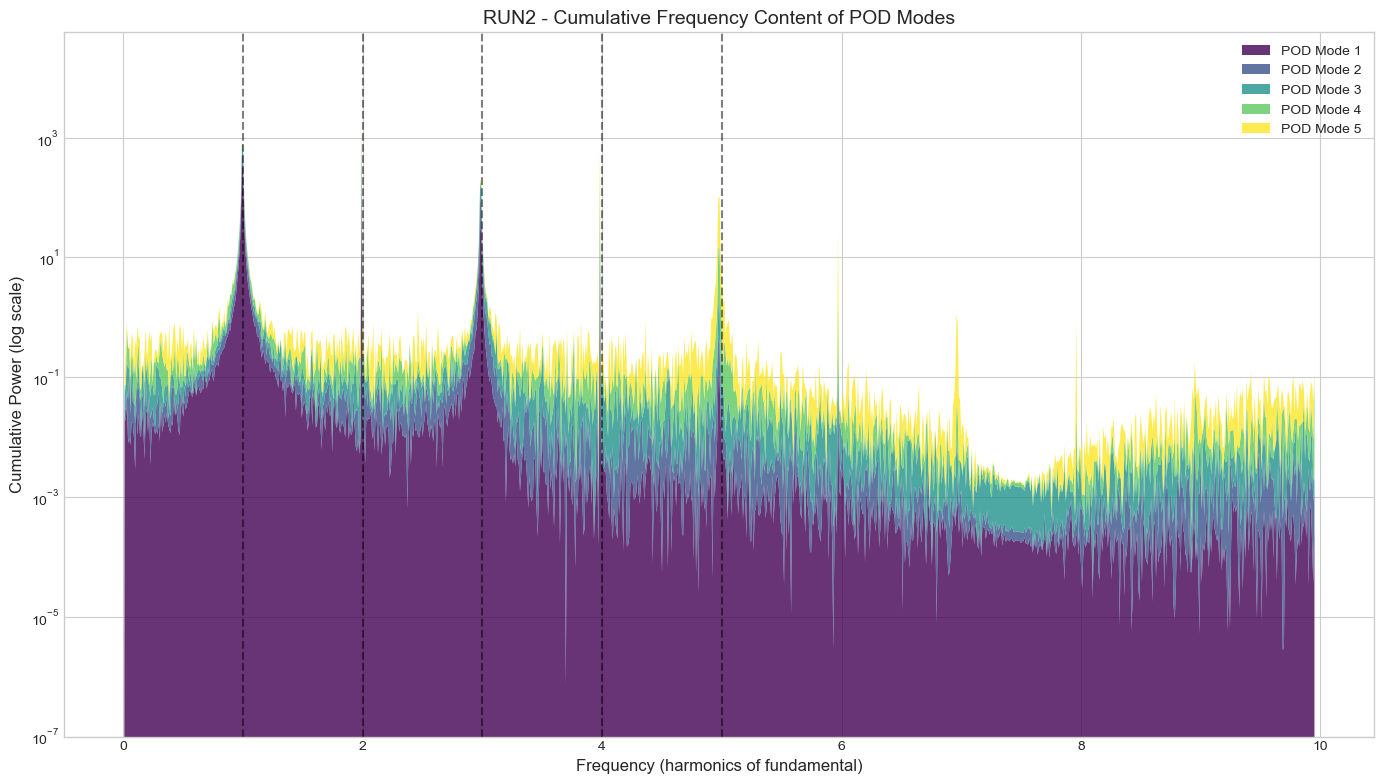

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py  # For reading MATLAB v7.3 files
import matplotlib as mpl

def analyze_pod_coefficients_frequency(pod_coeffs):
    """
    Analyze frequency content of POD temporal coefficients (psi)
    
    Args:
        pod_coeffs: POD temporal coefficients [n_snapshots, n_modes]
        
    Returns:
        freqs: Frequency array (in harmonics of actuation frequency)
        power_spectra: Power spectra for each mode [n_modes, n_freqs]
    """
    if pod_coeffs.shape[0] < pod_coeffs.shape[1]:
        pod_coeffs = pod_coeffs.T
    
    n_snapshots, n_modes = pod_coeffs.shape
    
    power_spectra = []
    for i in range(min(10, n_modes)):
        fft_coeffs = np.fft.rfft(pod_coeffs[:, i])
        power = np.abs(fft_coeffs)**2
        power_spectra.append(power)
    
    power_spectra = np.array(power_spectra)
    freqs = np.fft.rfftfreq(n_snapshots)
    
    # Normalize frequencies by the main peak of the most energetic POD mode (Mode 1)
    mode_0_spectrum = power_spectra[0]
    first_peak_idx = np.argmax(mode_0_spectrum[1:]) + 1
    first_peak_freq = freqs[first_peak_idx]
    
    # Avoid division by zero if no peak is found
    if first_peak_freq == 0:
        first_peak_freq = 1.0

    freqs_harmonic = freqs / first_peak_freq
    
    return freqs_harmonic, power_spectra

def compare_pod_spod(pod_mat_file, spod_npz_file, output_dir="comparisons"):
    """
    Compare POD and SPOD results in frequency domain.
    Saves plots to a folder and displays them in the notebook.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # --- Data Loading ---
    with h5py.File(pod_mat_file, 'r') as f:
        pod_coeffs = np.array(f['Psi']).T
    
    spod_data = np.load(spod_npz_file)
    spod_freqs = spod_data['freqs']
    spod_eigvals = spod_data['eigvals']
    
    run_name = os.path.basename(pod_mat_file).split('_')[0]
    
    # --- Analysis ---
    pod_freqs_harmonic, pod_power_spectra = analyze_pod_coefficients_frequency(pod_coeffs)
    
    # Normalize SPOD frequencies
    spod_peak_idx = np.argmax(spod_eigvals[1:, 0]) + 1
    spod_peak_freq = spod_freqs[spod_peak_idx]
    if spod_peak_freq == 0: spod_peak_freq = 1.0
    spod_freqs_harmonic = spod_freqs / spod_peak_freq
    
    # --- Normalization for Plotting ---
    # Normalize all POD spectra by the absolute maximum power found in Mode 1
    global_pod_max = np.max(pod_power_spectra[0])
    
    # Normalize all SPOD spectra by the absolute maximum energy found in Mode 1
    global_spod_max = np.max(spod_eigvals[:, 0])

    # --- Plotting Setup ---
    plt.style.use('seaborn-v0_8-whitegrid')
    mpl.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10})
    colors = plt.cm.viridis(np.linspace(0, 1, 5))

    # --- Plot 1: Main Comparison ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    
    # SPOD Spectrum
    for i in range(min(5, spod_eigvals.shape[1])):
        ax1.semilogy(spod_freqs_harmonic, spod_eigvals[:, i] / global_spod_max, 
                     label=f'SPOD Mode {i+1}', color=colors[i], lw=2)
    ax1.set_title(f"{run_name} - SPOD Eigenvalue Spectrum")
    ax1.set_ylabel("Normalized Energy")
    ax1.set_ylim(bottom=1e-7, top=2) # Set a floor to hide noise
    ax1.legend()

    # POD Spectrum
    for i in range(min(5, pod_power_spectra.shape[0])):
        ax2.semilogy(pod_freqs_harmonic, pod_power_spectra[i] / global_pod_max, 
                     label=f'POD Mode {i+1}', color=colors[i], lw=2)
    ax2.set_title(f"{run_name} - POD Coefficient Spectrum")
    ax2.set_xlabel("Frequency (harmonics of fundamental)")
    ax2.set_ylabel("Normalized Power")
    ax2.set_ylim(bottom=1e-7, top=2) # Set a floor to hide noise
    ax2.legend()

    for ax in [ax1, ax2]:
        for h in range(1, 6):
            ax.axvline(x=h, color='k', linestyle='--', alpha=0.5)
    
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{run_name}_pod_spod_comparison.png"), dpi=300)
    plt.show()  # <-- ADDED: Display the plot in the notebook

    # --- Plot 2: Stacked Area Plot of POD Frequency Content ---
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # We plot the actual power, not normalized, to show the decay
    y = pod_power_spectra[:5, :]
    
    ax.stackplot(pod_freqs_harmonic, y, labels=[f'POD Mode {i+1}' for i in range(5)], colors=colors, alpha=0.8)
    
    ax.set_yscale('log')
    ax.set_title(f"{run_name} - Cumulative Frequency Content of POD Modes")
    ax.set_xlabel("Frequency (harmonics of fundamental)")
    ax.set_ylabel("Cumulative Power (log scale)")
    ax.set_ylim(bottom=1e-7) # Set floor based on data
    ax.legend(loc='upper right')
    for h in range(1, 6):
        ax.axvline(x=h, color='k', linestyle='--', alpha=0.5)

    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{run_name}_pod_stacked_frequency.png"), dpi=300)
    plt.show()
    
    plt.close('all') # Clean up all figure objects from memory


compare_pod_spod("data/RUN2_PIV.mat", "SPOD_data/RUN2_PIV_SPOD.npz")

The comparative analysis between SPOD and POD starkly illustrates their fundamental differences in decomposing the flow dynamics. The SPOD results clearly isolate the flow's energy into frequency-specific modes, with the energy at each harmonic being overwhelmingly concentrated in the leading SPOD mode. This demonstrates SPOD's strength in identifying spatially coherent structures that oscillate at a single, distinct frequency. In contrast, the POD analysis reveals that the energy of each harmonic is distributed across multiple POD modes, as shown by the nearly identical frequency spectra for the first few modes. This indicates that while POD modes are optimal for capturing spatial energy, they are "frequency-blind," representing a superposition of different temporal scales within each mode. Therefore, for understanding the frequency-domain behavior and the specific structures associated with each harmonic, SPOD provides a much cleaner and more physically interpretable decomposition than the standard POD.